In [ ]:
import zipfile
import glob
import os

zip_file = glob.glob("/content/*.zip")[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/MNIST")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/MNIST"):
    for file in files:
        print(os.path.join(root, file))

/content/MNIST/mnist_train.csv
/content/MNIST/mnist_test.csv


CSV files found:
/content/MNIST/mnist_train.csv
/content/MNIST/mnist_test.csv

Training file: /content/MNIST/mnist_train.csv
Testing file : /content/MNIST/mnist_test.csv

Original training shape: (60001, 785)
Original testing shape : (10001, 785)

Label column: label

After cleaning:
X_train: (60000, 784)
y_train: (60000,)
X_test : (10000, 784)
y_test : (10000,)

Final image shapes:
Training: (60000, 28, 28, 1)
Testing : (10000, 28, 28, 1)


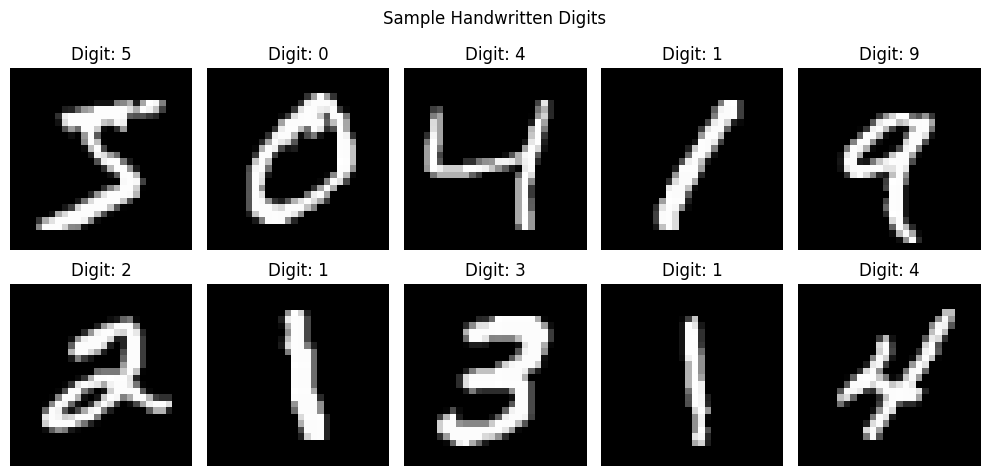

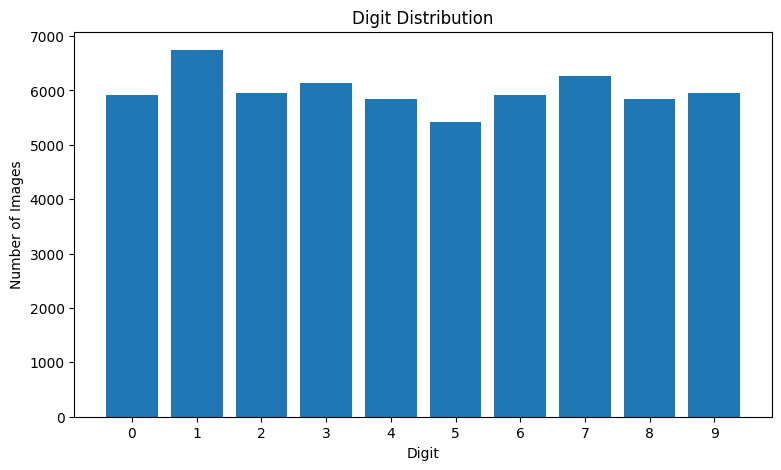


CNN model created successfully!
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.9177 - loss: 0.2732 - val_accuracy: 0.9827 - val_loss: 0.0600
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9772 - loss: 0.0775 - val_accuracy: 0.9895 - val_loss: 0.0400
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9829 - loss: 0.0566 - val_accuracy: 0.9873 - val_loss: 0.0448
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9913 - val_loss: 0.0310
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9885 - loss: 0.0372 - val_accuracy: 0.9913 - val_loss: 0.0308

MODEL PERFORMANCE
Test Accuracy: 99.1 %
Test Loss: 0.0277


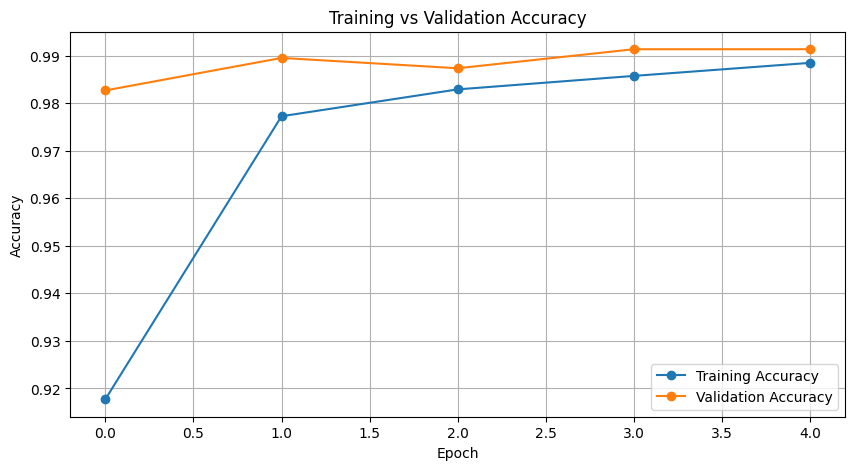

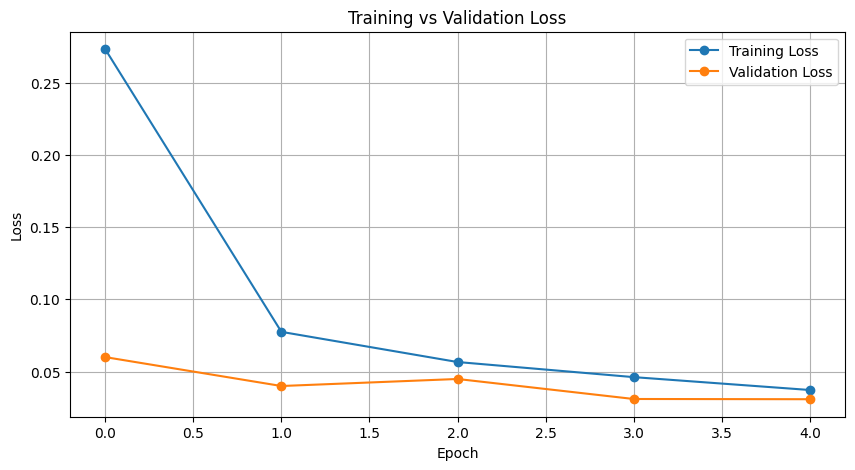

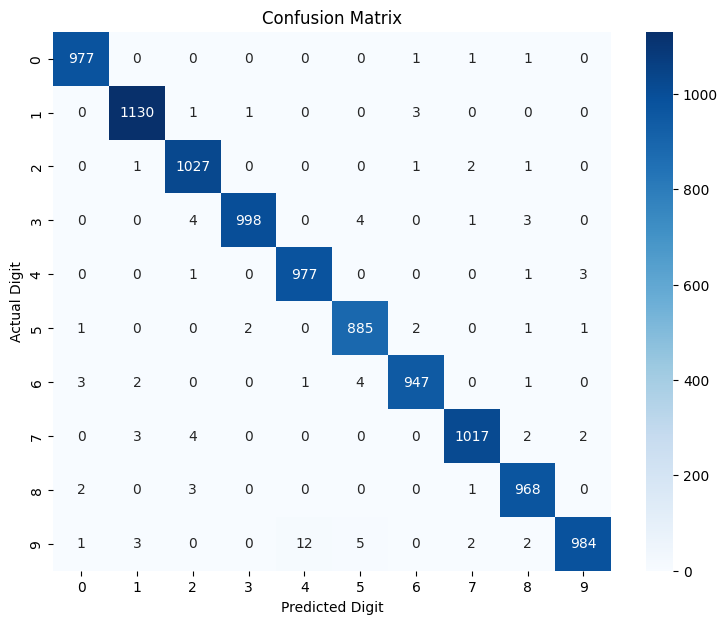


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      1.00      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



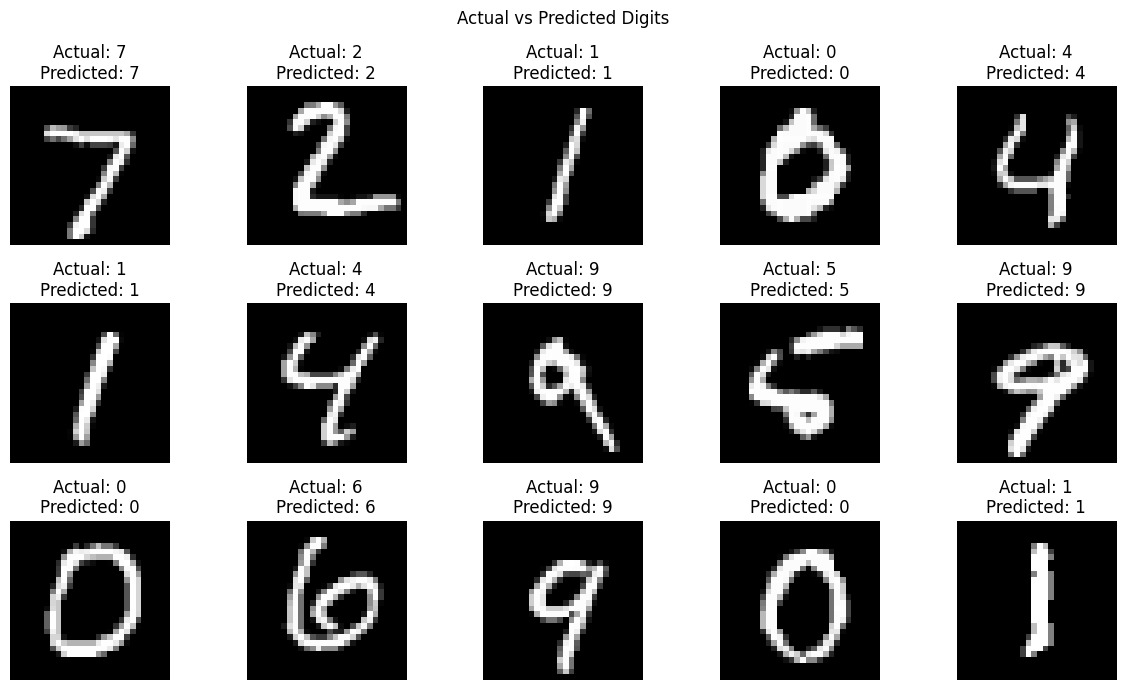


CODEALPHA TASK 3 COMPLETED
Dataset: MNIST
Model: CNN
Classes: 0 - 9
Final Test Accuracy: 99.1 %
Model saved successfully:
/content/handwritten_digit_model.keras


In [ ]:
# ============================================================
# CODEALPHA TASK 3 - HANDWRITTEN DIGIT RECOGNITION
# MNIST + CNN + VISUALIZATIONS
# FINAL FIXED VERSION
# ============================================================

!pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# ============================================================
# 1. FIND CSV FILES
# ============================================================

csv_files = glob.glob(
    "/content/MNIST/**/*.csv",
    recursive=True
)

print("CSV files found:")

for f in csv_files:
    print(f)

if len(csv_files) < 2:
    raise Exception("Training and testing CSV files were not found.")


# ============================================================
# 2. FIND TRAIN AND TEST FILES
# ============================================================

train_file = None
test_file = None

for f in csv_files:

    name = os.path.basename(f).lower()

    if "train" in name:
        train_file = f

    elif "test" in name:
        test_file = f


if train_file is None or test_file is None:
    raise Exception("Could not identify train/test CSV files.")


print("\nTraining file:", train_file)
print("Testing file :", test_file)


# ============================================================
# 3. LOAD DATA
# ============================================================

train_df = pd.read_csv(
    train_file,
    low_memory=False
)

test_df = pd.read_csv(
    test_file,
    low_memory=False
)

print("\nOriginal training shape:", train_df.shape)
print("Original testing shape :", test_df.shape)


# ============================================================
# 4. LABEL COLUMN
# ============================================================

if "label" in train_df.columns:
    label_column = "label"
else:
    label_column = train_df.columns[0]

print("\nLabel column:", label_column)


# ============================================================
# 5. SEPARATE X AND Y
# ============================================================

X_train_df = train_df.drop(
    columns=[label_column]
).copy()

y_train_series = train_df[
    label_column
].copy()


X_test_df = test_df.drop(
    columns=[label_column]
).copy()

y_test_series = test_df[
    label_column
].copy()


# ============================================================
# 6. CONVERT LABELS TO NUMBERS
# ============================================================

y_train_series = pd.to_numeric(
    y_train_series,
    errors="coerce"
)

y_test_series = pd.to_numeric(
    y_test_series,
    errors="coerce"
)


# ============================================================
# 7. REMOVE INVALID LABEL ROWS
#    IMPORTANT: SAME ROWS REMOVED FROM X AND Y
# ============================================================

train_mask = y_train_series.notna()
test_mask = y_test_series.notna()

X_train_df = X_train_df.loc[
    train_mask
].copy()

y_train_series = y_train_series.loc[
    train_mask
].copy()


X_test_df = X_test_df.loc[
    test_mask
].copy()

y_test_series = y_test_series.loc[
    test_mask
].copy()


# Reset indexes
X_train_df.reset_index(
    drop=True,
    inplace=True
)

y_train_series.reset_index(
    drop=True,
    inplace=True
)

X_test_df.reset_index(
    drop=True,
    inplace=True
)

y_test_series.reset_index(
    drop=True,
    inplace=True
)


# ============================================================
# 8. CONVERT PIXELS TO NUMBERS
# ============================================================

X_train_df = X_train_df.apply(
    pd.to_numeric,
    errors="coerce"
)

X_test_df = X_test_df.apply(
    pd.to_numeric,
    errors="coerce"
)


# Replace invalid pixel values such as "1x1"
X_train_df = X_train_df.fillna(0)
X_test_df = X_test_df.fillna(0)


# ============================================================
# 9. CONVERT TO NUMPY
# ============================================================

X_train = X_train_df.to_numpy(
    dtype="float32"
)

X_test = X_test_df.to_numpy(
    dtype="float32"
)

y_train = y_train_series.to_numpy(
    dtype="int32"
)

y_test = y_test_series.to_numpy(
    dtype="int32"
)


# ============================================================
# 10. KEEP 784 PIXEL COLUMNS
# ============================================================

if X_train.shape[1] > 784:
    X_train = X_train[:, :784]

if X_test.shape[1] > 784:
    X_test = X_test[:, :784]


print("\nAfter cleaning:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ============================================================
# 11. CHECK DATA SIZE
# ============================================================

if len(X_train) != len(y_train):
    raise Exception("Training X and y sizes do not match.")

if len(X_test) != len(y_test):
    raise Exception("Testing X and y sizes do not match.")


# ============================================================
# 12. NORMALIZE
# ============================================================

X_train = X_train / 255.0
X_test = X_test / 255.0


# ============================================================
# 13. RESHAPE 28 x 28
# ============================================================

X_train = X_train.reshape(
    -1, 28, 28, 1
)

X_test = X_test.reshape(
    -1, 28, 28, 1
)

print("\nFinal image shapes:")
print("Training:", X_train.shape)
print("Testing :", X_test.shape)


# ============================================================
# 14. ONE-HOT ENCODING
# ============================================================

y_train_cat = to_categorical(
    y_train,
    10
)

y_test_cat = to_categorical(
    y_test,
    10
)


# ============================================================
# VISUALIZATION 1 - SAMPLE DIGITS
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_train[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        "Digit: " + str(y_train[i])
    )

    plt.axis("off")

plt.suptitle(
    "Sample Handwritten Digits"
)

plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 2 - DIGIT DISTRIBUTION
# ============================================================

digits, counts = np.unique(
    y_train,
    return_counts=True
)

plt.figure(figsize=(9, 5))

plt.bar(
    digits,
    counts
)

plt.title(
    "Digit Distribution"
)

plt.xlabel("Digit")
plt.ylabel("Number of Images")

plt.xticks(range(10))

plt.show()


# ============================================================
# 15. CNN MODEL
# ============================================================

model = Sequential([

    Input(
        shape=(28, 28, 1)
    ),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 16. COMPILE
# ============================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nCNN model created successfully!")


# ============================================================
# 17. TRAIN
# ============================================================

history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


# ============================================================
# 18. EVALUATE
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("\n======================================")
print("MODEL PERFORMANCE")
print("======================================")

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

print(
    "Test Loss:",
    round(test_loss, 4)
)


# ============================================================
# VISUALIZATION 3 - ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# VISUALIZATION 4 - LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 19. PREDICTIONS
# ============================================================

predictions = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    predictions,
    axis=1
)


# ============================================================
# VISUALIZATION 5 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=range(10)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Digit"
)

plt.ylabel(
    "Actual Digit"
)

plt.show()


# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test,
        y_pred,
        labels=range(10),
        zero_division=0
    )
)


# ============================================================
# VISUALIZATION 6 - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(12, 7))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        "Actual: " + str(y_test[i]) +
        "\nPredicted: " + str(y_pred[i])
    )

    plt.axis("off")

plt.suptitle(
    "Actual vs Predicted Digits"
)

plt.tight_layout()
plt.show()


# ============================================================
# 21. SAVE MODEL
# ============================================================

model.save(
    "/content/handwritten_digit_model.keras"
)


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("CODEALPHA TASK 3 COMPLETED")
print("======================================")

print("Dataset: MNIST")
print("Model: CNN")
print("Classes: 0 - 9")

print(
    "Final Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

print(
    "Model saved successfully:"
)

print(
    "/content/handwritten_digit_model.keras"
)